In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from functools import lru_cache

## 1. Matrices de transitions

- Matrice joueur

In [2]:
R_j = np.array([
    #      21      22      23      24      25      26      27-30   A10
    [     0,      0,      0,      0,      0,       0,    0,0,0,0,                0],      # 0
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 2
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 3
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 4
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 5
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 6
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,               0],      # 7
    [      0,      0,      0,      0,      0,      0,    0,0,0,0,              0],      # 8
    [     0,      0,      0,      0,      0,       0,    0,0,0,0,               0],      # 9
    [    0,      0,      0,      0,       0,       0,    0,0,0,0,            1/13],      # 10
    [1/13,      0,      0,      0,        0,       0,    0,0,0,0,               0],      # 10+
    [4/13,      0,      0,      0,        0,       0,    0,0,0,0,               0],      # 11
    [1/13,  4/13,      0,      0,         0,       0,    0,0,0,0,               0],      # 12
    [1/13,  1/13,  4/13,      0,          0,       0,    0,0,0,0,               0],      # 13
    [1/13,  1/13,  1/13,  4/13,           0,       0,    0,0,0,0,               0],      # 14
    [1/13,  1/13,  1/13,  1/13,  4/13,            0,     0,0,0,0,               0],      # 15
    [1/13,  1/13,  1/13,  1/13,           1/13,   4/13,  0,0,0,0,               0],      # 16

    [1/13,  1/13,  1/13,  1/13,           1/13,   1/13,  4/13,0,0,0,            0],      # 17
    [1/13,  1/13,  1/13,  1/13,           1/13,   1/13,  1/13,4/13,0,0,         0],      # 18
    [1/13,  1/13,  1/13,  1/13,           1/13,   1/13,  1/13,1/13,4/13,0,      0],      # 19
    [1/13,  1/13,  1/13,  1/13,           1/13,   1/13,  1/13,1/13,1/13,4/13,   0],      # 20

    [      0,      0,      0,      0,      0,     0,      0,0,0,0,           4/13],      # A
    [  1/13,      0,      0,      0,      0,      0,      0,0,0,0,              0],      # AA
    [  1/13,      0,      0,      0,      0,      0,      0,0,0,0,              0],      # A2
    [  1/13,      0,      0,      0,      0,      0,      0,0,0,0,              0],      # A3
    [  1/13,      0,      0,      0,      0,      0,      0,0,0,0,              0],      # A4
    [  1/13,      0,      0,      0,      0,       0,     0,0,0,0,              0],      # A5

    [  1/13,      0,      0,      0,      0,       0,     0,0,0,0,              0],      # A6
    [  1/13,      0,      0,      0,      0,       0,     0,0,0,0,              0],      # A7
    [  1/13,      0,      0,      0,      0,       0,     0,0,0,0,              0],      # A8
    [  1/13,      0,      0,      0,      0,       0,     0,0,0,0,              0],      # A9
])
Q_j = np.array([
    # ligne "0"                                                                     #17 - 20                    #A- A5            # A6 - A9
    [0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 0,  0,0,0,0,                1/13, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 4/13, 0, 0, 0, 0,  0,0,0,0,                0, 0, 1/13, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 4/13, 0, 0, 0,  0,0,0,0,                0, 0, 0, 1/13, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0,  0,0,0,0,                0, 0, 0, 0, 1/13, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13, 0,  0,0,0,0,                0, 0, 0, 0, 0, 1/13,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13,  0,0,0,0,                0, 0, 0, 0, 0, 0,    1/13,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13,     4/13,0,0,0,             0, 0, 0, 0, 0, 0,    0,1/13,0,0], 
    #ligne 8 
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13,    1/13,4/13,0,0,              0, 0, 0, 0, 0, 0,    0,0,1/13,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13,       1/13,1/13,4/13,0,           0, 0, 0, 0, 0, 0,    0,0,0,1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13,1/13,1/13,4/13,        0, 0, 0, 0, 0, 0,    0,0,0,0],
    # 10 +
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13,1/13,1/13,4/13,        0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13,             1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13,                1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13,                   1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13,                      1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         1/13, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],

    #ligne 17-20
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         0, 1/13,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         0, 0 ,1/13,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         0, 0 , 0 ,1/13,       0, 0, 0, 0, 0, 0,    0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         0, 0 , 0 , 0 ,       0, 0, 0, 0, 0, 0,    0,0,0,0],

     # ligne "A"
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,                         0,0,0,0,     0, 1/13, 1/13, 1/13, 1/13, 1/13,      1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4/13, 0, 0, 0, 0,                      0,0,0,0,     0, 0, 1/13, 1/13, 1/13, 1/13,      1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 4/13, 0, 0, 0,                   0,0,0,0,     0, 0, 0, 1/13, 1/13, 1/13,      1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 4/13, 0, 0,                0,0,0,0,     0, 0, 0, 0, 1/13, 1/13,      1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 4/13, 0,             0,0,0,0,     0, 0, 0, 0, 0, 1/13,      1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 4/13,          0,0,0,0,     0, 0, 0, 0, 0, 0,      1/13, 1/13, 1/13, 1/13],
    # ligne A6
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          4/13,0,0,0,     0, 0, 0, 0, 0, 0,      0, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13,4/13,0,0,     0, 0, 0, 0, 0, 0,      0, 0, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13,1/13,4/13,0,     0, 0, 0, 0, 0, 0,      0, 0, 0, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13,          1/13,1/13,1/13,4/13,     0, 0, 0, 0, 0, 0,      0, 0, 0, 0],

   
])

I_j = np.eye(R_j.shape[1])       
O_j = np.zeros((R_j.shape[1], Q_j.shape[1]))  

P_j = np.block([
    [Q_j, R_j],
    [O_j, I_j]
])

N_j = np.linalg.inv(np.eye(Q_j.shape[0]) - Q_j)
B_j = N_j @ R_j

print(Q_j.shape)
print(R_j.shape) 
print(P_j.shape)
print(N_j.shape)
print(B_j.shape)

print(sum(P_j[28]))

(31, 31)
(31, 11)
(42, 42)
(31, 31)
(31, 11)
1.0


- Matrice croupier

In [3]:
R = np.array([
    # 17      18      19      20      21      22      23      24      25      26      A6      A7      A8      A9      A10
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 0
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 2
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 3
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 4
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 5
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13,      0,      0,      0,      0],      # 6
    [4/13,   0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13,      0,      0,      0],      # 7
    [1/13, 4/13,     0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13,      0,      0],      # 8
    [1/13, 1/13, 4/13,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13,      0],      # 9
    [1/13, 1/13, 1/13,  4/13,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13],      # 10
    [1/13, 1/13, 1/13,  4/13,  1/13,      0,      0,      0,      0,      0,      0,      0,      0,      0,        0],      # 10+
    [1/13, 1/13, 1/13,  1/13,  4/13,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 11
    [1/13, 1/13, 1/13,  1/13,  1/13,  4/13,      0,      0,      0,      0,      0,      0,      0,      0,      0],      # 12
    [1/13, 1/13, 1/13,  1/13,  1/13,  1/13,  4/13,      0,      0,      0,      0,      0,      0,      0,      0],      # 13
    [1/13, 1/13, 1/13,  1/13,  1/13,  1/13,  1/13,  4/13,      0,      0,      0,      0,      0,      0,      0],      # 14
    [1/13, 1/13, 1/13,  1/13,  1/13,  1/13,  1/13,  1/13,  4/13,      0,      0,      0,      0,      0,      0],      # 15
    [1/13, 1/13, 1/13,  1/13,  1/13,  1/13,  1/13,  1/13,  1/13,  4/13,      0,      0,      0,      0,      0],      # 16
    [0,      0,      0,      0,      0,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,  4/13],      # A
    [0,      0,      0,      0,  1/13,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,      0],      # AA
    [0,      0,      0,      0,  1/13,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,      0],      # A2
    [0,      0,      0,      0,  1/13,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,      0],      # A3
    [0,      0,      0,      0,  1/13,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,      0],      # A4
    [0,      0,      0,      0,  1/13,      0,      0,      0,      0,      0,  1/13,  1/13,  1/13,  1/13,      0],      # A5
])
Q = np.array([
    # ligne "0"
    [0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 0, 1/13, 0, 0, 0, 0, 0],
    [0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 0, 0, 0],
    [0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 0, 0],
    [0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 0],
    [0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1/13, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0], 
    #ligne 8 
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    # 10 +
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     # ligne "A"
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0, 1/13],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/13, 1/13, 1/13, 1/13, 4/13, 0, 0, 0, 0, 0, 0]
   
])

I = np.eye(15)       
O = np.zeros((15, 23))  

P = np.block([
    [Q, R],
    [O, I]
])

N = np.linalg.inv(np.eye(Q.shape[0]) - Q)
B = N @ R

print(Q.shape)
print(R.shape) 
print(P.shape)
print(N.shape)
print(B.shape)

print(sum(P[0]))

(23, 23)
(23, 15)
(38, 38)
(23, 23)
(23, 15)
1.0


In [4]:
somme_lignes = N.sum(axis=1)

print(somme_lignes)

[2.9062089  2.70509278 2.58384421 2.46559734 2.35849748 2.15069629
 1.79136052 1.67136508 1.55994074 1.4485164  1.4485164  1.4485164
 1.34505094 1.24897588 1.15976331 1.07692308 1.         1.7002557
 1.96310913 1.8915121  1.82012735 1.74928985 1.67928563]


## 2. Calcul esperance et proba de STAND à partir de B croupier

In [4]:
## B_0 Croupier

etats_absorbants_c = ['17', '18', '19', '20', '21', '22', '23', '24', '25', 
                    '26', 'A6', 'A7',  'A8', 'A9','A10']
etats_non_absorbants_c = [
    "0", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+",
    "11", "12", "13", "14", "15", "16", "A", "AA", "A2", "A3", "A4", "A5"
]

map_to_Ace = {
              '11': 'A',
              '12': 'AA',
              '13': 'A2', 
              '14': 'A3',
              '15': 'A4', 
              '16': 'A5',     
              '17': 'A6', 
              '18': 'A7',
              '19': 'A8', 
              '20': 'A9',
              '21':'A10'   
            }

hand_to_value ={
    "0":'0', 
    "2":'2', 
    "3":'3', 
    "4":"4", 
    "5":"5", 
    "6":"6", 
    "7":"7", 
    "8":"8", 
    "9":"9", 
    "10":"10", 
    "10+":"10",
    "11":"11", 
    "12":"12", 
    "13":"13", 
    "14":"14", 
    "15":"15", 
    "16":"16", 
    "17":"17", 
    "18":"18", 
    "19":"19", 
    "20":"20",
    "21":"21",
    "22":"22", 
    "23":"23",
    "24":"24", 
    "25":"25",
    "26":"26",
    "27":"27",
    "28":"28",
    "29":"29",
    "30":"30",
    "A":"11", 
    "AA":"12", 
    "A2":"13", 
    "A3":"14", 
    "A4":"15", 
    "A5":"16", 
    "A6":"17", 
    "A7":"18", 
    "A8":"19", 
    "A9":"20",
    "A10" : "21"
}

croupier_eg = ['17','18','19','20','21','A6','A7','A8','A9','A10']


B_0 = pd.DataFrame(B, columns=etats_absorbants_c, index = etats_non_absorbants_c)
B_0.index.name = 'Carte_croupier'
B_0.columns.name = 'Arrivée croupier'

Proba win et égalité de rester

In [5]:
def proba_win(player_hand, croupier_card, B, esperance=False):
    p = sum(B.loc[croupier_card][['22', '23', '24', '25', '26']])

    num_player_hand = int(hand_to_value[player_hand])

    if num_player_hand > 21 : 
        return 0
    
    list_p = [str(item) for i in range(17, num_player_hand) for item in (i, map_to_Ace[str(i)])]
    
    if player_hand == 'A10':
        list_p.append('21')

    p+= sum(B.loc[croupier_card][list_p])

    if esperance ==True and player_hand == 'A10':
        p = p * 1.5
        
    return p


def proba_draw(player_hand, croupier_card, B):
    if player_hand not in croupier_eg : # SI pas au moins 17
        return 0
    
    if player_hand != 'A10' and player_hand != '21' : 
        other = hand_to_value[player_hand] if (player_hand.startswith('A'))  else map_to_Ace[player_hand]
        #print(other)
        return B.loc[croupier_card][player_hand] + B.loc[croupier_card][other]
    
    return B.loc[croupier_card][player_hand]


print(proba_win('20', '6', B_0)) 
print(proba_draw('20', '6', B_0))
print(1 - proba_draw('20', '6', B_0) - proba_win('20', '6', B_0))
print(proba_win('22', '6', B_0))
print(proba_draw('22', '6', B_0))


0.8011218263287647
0.1017149175138152
0.09716325615742005
0
0


In [6]:
main_joueur_0 = ['16', '17', '18', '19', '20', '21', 'A10']
index_outcome = ['Victoire', 'Egalité', 'Défaite']
carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

index = pd.MultiIndex.from_product([main_joueur_0, index_outcome],
                                   names=["Score joueur", "Outcome"])

W_0 = pd.DataFrame(index=index, columns=carte_croupier)
W_0.columns.name = "Carte croupier"

for c in carte_croupier:
    p_win = [proba_win(m, c, B_0, esperance=True) for m in main_joueur_0]
    p_true_win = [proba_win(m, c, B_0) for m in main_joueur_0]
    p_draw = [proba_draw(m, c, B_0) for m in main_joueur_0]
    p_lose = [1 - (i + j) for (i, j) in zip(p_true_win, p_draw)]

    col_values = []
    for w, d, l in zip(p_win, p_draw, p_lose):
        col_values.extend([w, d, l])  # ordre Victoire, Egalité, Défaite

    W_0[c] = [val for val in col_values]

W_0 = W_0.rename(index={"16": "4-16"})
W_0

Carte croupier                2             3             4             5  \
Score joueur Outcome                                                        
4-16         Victoire  0.353608  3.738749e-01  3.944684e-01  4.164037e-01   
             Egalité   0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
             Défaite   0.646392  6.261251e-01  6.055316e-01  5.835963e-01   
17           Victoire  0.353608  3.738749e-01  3.944684e-01  4.164037e-01   
             Egalité   0.139809  1.350340e-01  1.304897e-01  1.222513e-01   
             Défaite   0.506583  4.910911e-01  4.750418e-01  4.613450e-01   
18           Victoire  0.493417  5.089089e-01  5.249582e-01  5.386550e-01   
             Egalité   0.134907  1.304823e-01  1.259381e-01  1.222513e-01   
             Défaite   0.371675  3.606088e-01  3.491037e-01  3.390938e-01   
19           Victoire  0.628325  6.393912e-01  6.508963e-01  6.609062e-01   
             Egalité   0.129655  1.255805e-01  1.213864e-01  1.176996e-01   
             Défaite   0.242020  2.350283e-01  2.277173e-01  2.213941e-01   
20           Victoire  0.757980  7.649717e-01  7.722827e-01  7.786059e-01   
             Egalité   0.124026  1.203286e-01  1.164846e-01  1.131480e-01   
             Défaite   0.117993  1.146996e-01  1.112327e-01  1.082462e-01   
21           Victoire  0.882007  8.853004e-01  8.887673e-01  8.917538e-01   
             Egalité   0.117993  1.146996e-01  1.112327e-01  1.082462e-01   
             Défaite   0.000000 -2.220446e-16 -2.220446e-16 -2.220446e-16   
A10          Victoire  1.500000  1.500000e+00  1.500000e+00  1.500000e+00   
             Egalité   0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
             Défaite   0.000000 -2.220446e-16 -2.220446e-16 -2.220446e-16   

Carte croupier                6             7             8         9  \
Score joueur Outcome                                                    
4-16         Victoire  0.423150  2.623124e-01  2.447412e-01  0.228425   
             Egalité   0.000000  0.000000e+00  0.000000e+00  0.000000   
             Défaite   0.576850  7.376876e-01  7.552588e-01  0.771575   
17           Victoire  0.423150  2.623124e-01  2.447412e-01  0.228425   
             Egalité   0.165438  3.685662e-01  1.285665e-01  0.119995   
             Défaite   0.411411  3.691214e-01  6.266922e-01  0.651579   
18           Victoire  0.588589  6.308786e-01  3.733078e-01  0.348421   
             Egalité   0.106267  1.377970e-01  3.593358e-01  0.119995   
             Défaite   0.305145  2.313244e-01  2.673564e-01  0.531584   
19           Victoire  0.694855  7.686756e-01  7.326436e-01  0.468416   
             Egalité   0.106267  7.862537e-02  1.285665e-01  0.350765   
             Défaite   0.198878  1.526991e-01  1.387899e-01  0.180819   
20           Victoire  0.801122  8.473009e-01  8.612101e-01  0.819181   
             Egalité   0.101715  7.862537e-02  6.939495e-02  0.119995   
             Défaite   0.097163  7.407370e-02  6.939495e-02  0.060824   
21           Victoire  0.902837  9.259263e-01  9.306051e-01  0.939176   
             Egalité   0.097163  7.407370e-02  6.939495e-02  0.060824   
             Défaite   0.000000 -2.220446e-16 -2.220446e-16  0.000000   
A10          Victoire  1.500000  1.500000e+00  1.500000e+00  1.500000   
             Egalité   0.000000  0.000000e+00  0.000000e+00  0.000000   
             Défaite   0.000000 -2.220446e-16 -2.220446e-16  0.000000   

Carte croupier               10         A  
Score joueur Outcome                       
4-16         Victoire  0.212109  0.115286  
             Egalité   0.000000  0.000000  
             Défaite   0.787891  0.884714  
17           Victoire  0.212109  0.115286  
             Egalité   0.111424  0.130789  
             Défaite   0.676467  0.753925  
18           Victoire  0.323533  0.246075  
             Egalité   0.111424  0.130789  
             Défaite   0.565042  0.623136  
19           Victoire  0.434958  0.376864  
             Egalité

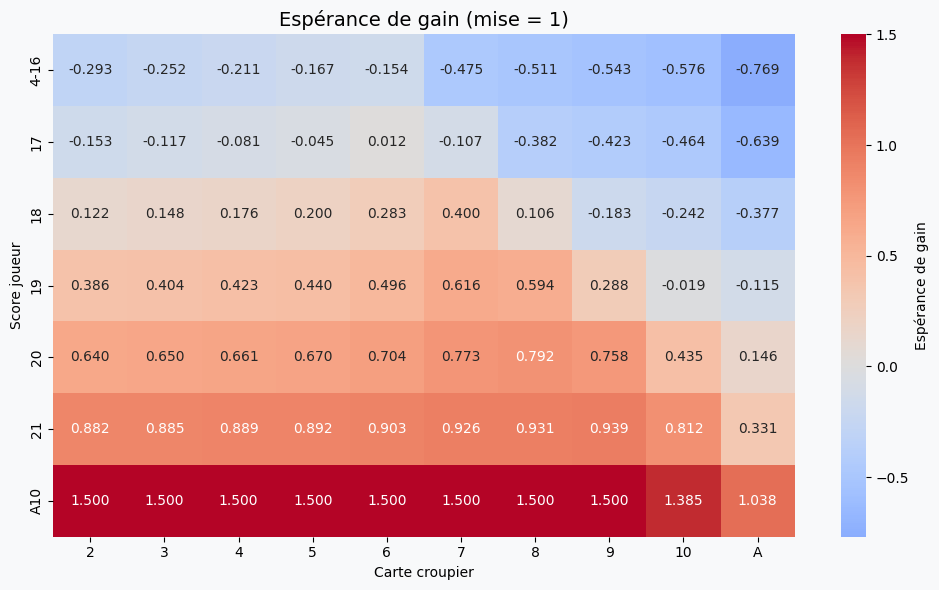

In [7]:
P_win  = W_0.xs("Victoire", level="Outcome")
P_draw = W_0.xs("Egalité",  level="Outcome")
P_lose = W_0.xs("Défaite",  level="Outcome")

E_gain_W_0 = P_win - P_lose

E_gain_W_0.index.name = "Score joueur"
E_gain_W_0.columns.name = "Carte croupier"
E_gain_W_0


# --- Heatmap ---
plt.figure(figsize=(10,6), facecolor="#f8f9fa")
sns.heatmap(E_gain_W_0, annot=True, cmap="coolwarm", center=0, fmt=".3f",
            cbar_kws={"label": "Espérance de gain"})
plt.title("Espérance de gain (mise = 1)", fontsize=14)
plt.ylabel("Score joueur")
plt.xlabel("Carte croupier")
plt.tight_layout()
plt.show()

## 3. Calcul espérance et probas TIRER

In [8]:
etats_absorbants_j = ['21', '22', '23', '24', '25', 
                    '26', '27','28', '29', '30', 'A10']
etats_non_absorbants_j = [
    "0", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+",
    "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", 
    "A", "AA", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9"
]

list_Pj = [np.linalg.matrix_power(P_j, l) for l in range(1, 5)]
list_df_pj = []

for pj in list_Pj :
    P_j_1 = pd.DataFrame(pj, columns=etats_non_absorbants_j + etats_absorbants_j, index = etats_non_absorbants_j + etats_absorbants_j)
    P_j_1.index.name = 'Carte_joueur'
    P_j_1.columns.name = 'Arrivée_joueur'
    list_df_pj.append(P_j_1)


In [9]:
inf_22 = ['0','2','3','4','5','6','7','8','9','10','10+','11','12','13','14','15','16','17','18','19','20','21','A','AA','A2','A3','A4','A5','A6','A7','A8','A9','A10']
croupier_eg = ['17','18','19','20','21','A6','A7','A8','A9','A10']


def proba_win_k(player_hand, croupier_card, B, P_j, esperance=False, split=False):
    p_c_tau_sup_22 = sum(B.loc[croupier_card][['22', '23', '24', '25', '26']])
    p_tot = 0 

    for j in inf_22: ## j is next card
        num_player_hand = int(hand_to_value[j])
        list_p = [str(item) for i in range(17, num_player_hand) for item in (i, map_to_Ace[str(i)])] # list_p is dealer cards that make player win 
        if j == 'A10' and split==False:
            list_p.append('21')

        p_vnk = P_j.loc[player_hand][j] * (p_c_tau_sup_22 + sum(B.loc[croupier_card][list_p]))
        
        if j == 'A10' and esperance==True:
            p_vnk = p_vnk * 1.5

        p_tot += p_vnk
        #print(j,":", P_j.loc[player_hand][j])
        #print(list_p)
        #print(p_vnk)
        #print()
    return p_tot


def proba_draw_k(player_hand, croupier_card, B, P_j, split= False):
    p_tot = 0
    for j in croupier_eg:

        if split == True and j == 'A10':
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card]['21']

        else : 
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card][j] 
        
        if j != 'A10' and j != '21' : 
            other = hand_to_value[j] if (j.startswith('A'))  else map_to_Ace[j]
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card][other]
            #print(other)

        #print(j,":", P_j.loc[player_hand][j])
        #print(B.loc[croupier_card][j])
        #print()
            
    return p_tot

def proba_bust(player_hand, P_j):
    bust = ['22', '23', '24', '25', '26', '27', '28', '29', '30']
    p = 0
    for b in bust : 
        p +=  P_j.loc[player_hand][b]

    return p

## 4. Calcul choix optimal 

In [10]:
def esperance_stand(player_hand, croupier_hand) :
    return proba_win(player_hand, croupier_hand, B_0, esperance=True) - (1 - proba_win(player_hand, croupier_hand, B_0)-  proba_draw(player_hand, croupier_hand, B_0) )

In [11]:
#rajout du split dans 1 - probawin,  hit qu'une seule fois
def esperance_hit(p_hand, c_hand, e=True, split=False, split_ace = False) :
    if split_ace : # seulement 1 seul tirage et pas de blackjack
        return proba_win_k(p_hand, c_hand, B_0, list_df_pj[0], esperance=False, split=True) - (1 - proba_win_k(p_hand, c_hand, B_0, list_df_pj[0], split=True) -  proba_draw_k(p_hand, c_hand, B_0, list_df_pj[0], split=True))
    
    list_prob = [proba_win_k(p_hand, c_hand, B_0, p_j, esperance=e, split=split) - (1 - proba_win_k(p_hand, c_hand, B_0, p_j) -  proba_draw_k(p_hand, c_hand, B_0, p_j)) for p_j in list_df_pj]
    return max(list_prob)
    

In [12]:
def esperance_double(p_hand, c_hand, e=True, split=False, t=0) :
    if p_hand == '21' or p_hand == 'A10': 
        return -2
    p_simple = proba_win_k(p_hand, c_hand, B_0, list_df_pj[t], esperance=e, split=split) - (1 - proba_win_k(p_hand, c_hand, B_0, list_df_pj[t], split=split) -  proba_draw_k(p_hand, c_hand, B_0, list_df_pj[t], split=split))
    return 2 * p_simple

In [13]:
def can_split(p_hand): 
    return p_hand in ['4', '6', '8', '10', '12', '14', '16', '18', '20', 'AA']

In [14]:
def MDP(croupier_card, gamma = 1.0, epsilon = 1e-8, return_delta = False):
    S = inf_22
    V = {s: 0.0 for s in S}
    pi = {s: 'S' for s in S}
    Q_star = {k: {'S':0, 'T':0} for k in S}

    A = ['S', 'T']
    c = croupier_card #carte croupier
    iteration = 0

    epsilon = epsilon 
    gamma = gamma

    list_delta = []

    while True : 
        delta = 0
        V_new = V.copy()
        for s in S : 
            q_values = []
            for a in A : 
                r_s_a = esperance_stand(s, c) if a =='S' else - proba_bust(s, list_df_pj[0])
                q = r_s_a
                if a  == 'T' : 
                    for s_ in S :
                        q +=  gamma * list_df_pj[0].loc[s][s_]* V[s_]

                Q_star[s][a] = q        
                q_values.append(q)

            V_new[s] = max(q_values)
            
            if np.argmax(q_values)==1:
                pi[s]='T'
            else : 
                pi[s]='S'

            delta = max(delta, abs(V_new[s] - V[s]))
            
        V = V_new
        iteration += 1
        list_delta.append(delta)

        if delta < epsilon : 
            break
        

    if return_delta : 
        return V, Q_star, pi, list_delta

    return V, Q_star, pi, iteration


In [15]:
dic_esperance_hit = {k: {v: 0 for v in carte_croupier} for k in inf_22}

for c in carte_croupier : 
    V, Q_star, pi, i = MDP(croupier_card=c)
    for j in inf_22 : 
        dic_esperance_hit[j][c] = Q_star[j]['T']


In [17]:
def esperance_split_new(p_hand, c_hand) :
    new_hand = None
    if p_hand == 'AA': 
        new_hand = 'A'
    elif p_hand == '20':
        new_hand = '10+'
    else : 
        new_hand = str(int(p_hand) //2)

    e = 0
    for s in inf_22 : 
        p = list_df_pj[0].loc[new_hand][s]

        e_s = esperance_stand(s, c_hand) 


        if new_hand != 'A' : 
            e_h = dic_esperance_hit[s][c_hand]
            e_d = esperance_double(s,c_hand)

        else : 
            
            if s == 'A10' : 
                e_s = esperance_stand('21', c_hand) 
            e_h = esperance_hit(s, c_hand, split_ace=True) ## OK un seul tirage
            e_d = esperance_double(s, c_hand, e=False, split=True) 

        e += p * max(e_s, e_h, e_d)
    
    if new_hand == 'A': ## Pas de splits suppplémentaires
        return 2 * e

    return 2 * max((13/12) *  e, e)

# PREDICTIONS

In [551]:
def color_cell(val):
    colors = {
        "S": "background-color: lightcoral; color: lightred;",
        "H": "background-color: lightgreen;",

        "Dh": "background-color: lightblue;", 
        "Ds": "background-color: lightblue;",

        "Ah": "background-color: lightyellow;", 
        "As": "background-color: lightyellow;",

        "SP": "background-color: plum;"
    }
    return colors.get(val, "")  # couleur par défaut (vide ici)

In [573]:
### HARD TOTALS V2


main_joueur_k = ['4', '5','6','7','8','9','10+','11','12','13','14','15','16','17','18','19','20']
carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

choice_matrix_hard = np.empty((len(main_joueur_k), len(carte_croupier)), dtype='<U20')
max_e_matrix_hard = np.zeros((len(main_joueur_k), len(carte_croupier)))

for i, m in enumerate(main_joueur_k) : 
    for j, c in enumerate(carte_croupier) :

        e_stand = esperance_stand(m, c) 
        e_hit = dic_esperance_hit[m][c]
        e_double = esperance_double(m,c)
        e_a = -0.5

        max_e = max(e_stand, e_hit, e_double, e_a)

        choice = ''
        if max_e == e_stand :
            choice = 'S'

        elif max_e == e_hit : 
            choice = 'H'
            
        elif max_e == e_double :
            other_max = max(e_stand, e_hit, e_a) 
            if other_max == e_stand : 
                choice = 'Ds'
            elif other_max == e_hit : 
                choice = 'Dh'
            else : 
                choice = 'Da'
        else : 
            other_max = max(e_stand, e_hit, e_double)
            if other_max == e_stand : 
                choice = 'As'
            elif other_max == e_hit : 
                choice = 'Ah'
            else : 
                choice = 'Ad'

        choice_matrix_hard[i][j] = choice
        max_e_matrix_hard[i][j] = max_e


choix_hard = pd.DataFrame(choice_matrix_hard, index=main_joueur_k, columns=carte_croupier)
choix_hard.columns.name = "Carte croupier"
choix_hard.index.name = "Main joueur"

choix_hard = choix_hard.style.map(color_cell)
choix_hard
#OK 

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,H,H,H,H,H,H,H,H,H,H
5,H,H,H,H,H,H,H,H,H,Ah
6,H,H,H,H,H,H,H,H,H,Ah
7,H,H,H,H,H,H,H,H,H,Ah
8,H,H,H,H,H,H,H,H,H,H
9,H,Dh,Dh,Dh,Dh,H,H,H,H,H
10+,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
11,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,H,H,S,S,S,H,H,H,H,Ah


In [574]:
### SOFT TOTALS


main_joueur_k = ['AA', 'A2','A3','A4','A5','A6','A7','A8','A9']
carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

choice_matrix_soft = np.empty((len(main_joueur_k), len(carte_croupier)), dtype='<U20')
max_e_matrix_soft = np.zeros((len(main_joueur_k), len(carte_croupier)))

for i, m in enumerate(main_joueur_k) : 
    for j, c in enumerate(carte_croupier) :

        e_stand = esperance_stand(m, c) 
        e_hit = dic_esperance_hit[m][c]
        e_double = esperance_double(m,c)
        e_a = -0.5

        max_e = max(e_stand, e_hit, e_double, e_a)

        choice = ''
        if max_e == e_stand :
            choice = 'S'

        elif max_e == e_hit : 
            choice = 'H'
            
        elif max_e == e_double :
            other_max = max(e_stand, e_hit, e_a) 
            if other_max == e_stand : 
                choice = 'Ds'
            elif other_max == e_hit : 
                choice = 'Dh'
            else : 
                choice = 'Da'
        else : 
            other_max = max(e_stand, e_hit, e_double)
            if other_max == e_stand : 
                choice = 'As'
            elif other_max == e_hit : 
                choice = 'Ah'
            else : 
                choice = 'Ad'

        choice_matrix_soft[i][j] = choice
        max_e_matrix_soft[i][j] = max_e


choix_soft = pd.DataFrame(choice_matrix_soft, index=main_joueur_k, columns=carte_croupier)
choix_soft.columns.name = "Carte croupier"
choix_soft.index.name = "Main joueur"

choix_soft = choix_soft.style.map(color_cell)
choix_soft


Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
AA,H,H,H,H,H,H,H,H,H,H
A2,H,H,H,H,Dh,H,H,H,H,H
A3,H,H,H,Dh,Dh,H,H,H,H,H
A4,H,H,H,Dh,Dh,H,H,H,H,H
A5,H,H,Dh,Dh,Dh,H,H,H,H,H
A6,H,Dh,Dh,Dh,Dh,H,H,H,H,H
A7,S,Ds,Ds,Ds,Ds,S,S,H,H,H
A8,S,S,S,S,S,S,S,S,S,S
A9,S,S,S,S,S,S,S,S,S,S


In [575]:
a = esperance_double('A2', '5')
b = dic_esperance_hit['A2']['5']

print(a)
print(b)  

0.12595448524868003
0.13336273848321736


In [576]:
### PAIR TOTALS MODIFIED


main_joueur_k = ['4','6','8','10','12','14','16','18','20','AA']
carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

choice_matrix_pair = np.empty((len(main_joueur_k), len(carte_croupier)), dtype='<U20')
max_e_matrix_pair = np.zeros((len(main_joueur_k), len(carte_croupier)))

for i, m in enumerate(main_joueur_k) : 
    for j, c in enumerate(carte_croupier) :

        e_stand = esperance_stand(m, c) 
        e_hit = dic_esperance_hit[m][c]
        e_double = esperance_double(m,c)
        e_split = esperance_split_new(m,c) if can_split(m) else -np.inf
        e_a = -0.5

        max_e = max(e_stand, e_hit, e_double, e_split, e_a)

        choice = ''
        if max_e == e_stand :
            choice = 'S'

        elif max_e == e_hit : 
            choice = 'H'

        elif max_e == e_split: 
            choice = 'SP'
            
        elif max_e == e_double :
            other_max = max(e_stand, e_hit, e_a) 
            if other_max == e_stand : 
                choice = 'Ds'
            elif other_max == e_hit : 
                choice = 'Dh'
            else : 
                choice = 'Da'
        else : 
            other_max = max(e_stand, e_hit, e_double)
            if other_max == e_stand : 
                choice = 'As'
            elif other_max == e_hit : 
                choice = 'Ah'
            else : 
                choice = 'Ad'

        choice_matrix_pair[i][j] = choice
        max_e_matrix_pair[i][j] = max_e

choix_pair = pd.DataFrame(choice_matrix_pair, index=main_joueur_k, columns=carte_croupier)
choix_pair.columns.name = "Carte croupier"
choix_pair.index.name = "Main joueur"

choix_pair = choix_pair.style.map(color_cell)
choix_pair


Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,SP,SP,SP,SP,SP,SP,H,H,H,H
6,SP,SP,SP,SP,SP,SP,H,H,H,Ah
8,H,H,H,SP,SP,H,H,H,H,H
10,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,SP,SP,SP,SP,SP,H,H,H,H,Ah
14,SP,SP,SP,SP,SP,SP,H,H,Ah,Ah
16,SP,SP,SP,SP,SP,SP,SP,SP,Ah,Ah
18,SP,SP,SP,SP,SP,SP,SP,SP,S,S
20,S,S,S,S,S,S,S,S,S,S


In [577]:
a = esperance_stand('18', '7')
b = esperance_split_new('18', '7')

print(a)
print(b)  ## tres proche

0.3995541673365518
0.4008373561529438


In [579]:
a = dic_esperance_hit['AA']['A']
b = esperance_split_new('AA','A')

print(a)
print(b)  ## tres proche

-0.3218692999451668
-0.32865132395778074


In [580]:
css = """
<style>
table {
  border-collapse: collapse;
  font-family: 'Inter', Arial, sans-serif;
  font-size: 13px;         /* plus petit texte */
  margin: 0.5em 0;
  width: auto;
  
}
td, th {
  border: 1px solid #ccc;
  padding: 4px 8px;         /* cellules plus étroites */
  text-align: center;
}
tr:hover {
  background-color: #f9f9f9;
}
th {
  background-color: #f0f0f0;
  font-weight: 600;
}
</style>
"""

In [581]:
nom = ['choix_hard', 'choix_soft','choix_pair']
titre = [
    '<p style="text-align:center; font-weight:normal; font-size:16px; margin:8px 0;">Main "hard"</p>\n',
    '<p style="text-align:center; font-weight:normal; font-size:16px; margin:8px 0;">Main "soft"</p>\n',
    '<p style="text-align:center; font-weight:normal; font-size:16px; margin:8px 0;">Main paire</p>\n'
]
for i, df in enumerate([choix_hard, choix_soft, choix_pair]):
    html = css + titre[i] +  df.to_html()
    with open(f"{nom[i]}.html", "w", encoding="utf-8") as f:
        f.write(html)

In [79]:
choix_hard.to_html()

'<style type="text/css">\n#T_99a29_row0_col0, #T_99a29_row0_col1, #T_99a29_row0_col2, #T_99a29_row0_col3, #T_99a29_row0_col4, #T_99a29_row0_col5, #T_99a29_row0_col6, #T_99a29_row0_col7, #T_99a29_row0_col8, #T_99a29_row0_col9, #T_99a29_row1_col0, #T_99a29_row1_col1, #T_99a29_row1_col2, #T_99a29_row1_col3, #T_99a29_row1_col4, #T_99a29_row1_col5, #T_99a29_row1_col6, #T_99a29_row1_col7, #T_99a29_row1_col8, #T_99a29_row2_col0, #T_99a29_row2_col1, #T_99a29_row2_col2, #T_99a29_row2_col3, #T_99a29_row2_col4, #T_99a29_row2_col5, #T_99a29_row2_col6, #T_99a29_row2_col7, #T_99a29_row2_col8, #T_99a29_row3_col0, #T_99a29_row3_col1, #T_99a29_row3_col2, #T_99a29_row3_col3, #T_99a29_row3_col4, #T_99a29_row3_col5, #T_99a29_row3_col6, #T_99a29_row3_col7, #T_99a29_row3_col8, #T_99a29_row4_col0, #T_99a29_row4_col1, #T_99a29_row4_col2, #T_99a29_row4_col3, #T_99a29_row4_col4, #T_99a29_row4_col5, #T_99a29_row4_col6, #T_99a29_row4_col7, #T_99a29_row4_col8, #T_99a29_row4_col9, #T_99a29_row5_col0, #T_99a29_row5_

In [112]:
dic_esperance_hit['A4']['4']

0.05928537693118015

In [113]:
esperance_double('A4', '4')

0.05842651874374616

# Probeleme de ruine du joueur

In [532]:
values = [-10, 0, 10, 15]
probas = [0.65, 0.1, 0.2, 0.05]
n = 100
p =  10 * 0.2 + 15 *0.05
q =  0.65 * 10

trajectoires = []

for i in range(1000) : 
    list_Y_n = np.random.choice(values, n, p=probas)
    list_S_n = [sum(list_Y_n[:i]) for i in range(1, len(list_Y_n)+1)]
    list_un = [(q/p)**i for i in list_S_n]
    trajectoires.append(list_un)



tra = np.array(trajectoires)
np.mean(tra[:,9])


#un = [(q/p)**sn for sn in list_S_n]

5.681148311952375e+28

In [559]:
values = [-10, 10]
probas = [0.55 , 0.45]
n = 100

p =  0.45
q =  0.55 

trajectoires = []

for i in range(10000) : 
    list_Y_n = np.random.choice(values, n, p=probas)
    list_S_n = [sum(list_Y_n[:i]) for i in range(1, len(list_Y_n)+1)]
    list_un = [(q/p)**(i/10) for i in list_S_n]
    trajectoires.append(list_un)



tra = np.array(trajectoires)
np.mean(tra[:,99])


#un = [(q/p)**sn for sn in list_S_n]

1.0204337022492382

In [700]:
values = [-1, 1]
n = 100
q =  0.45
p = 1 - q
 

trajectoires = []

for i in range(10000) : 
    list_Y_n = np.random.choice(values, n, p=[q, p])
    list_S_n = [sum(list_Y_n[:i]) for i in range(1, len(list_Y_n)+1)]
    list_un = [(q/p)**i for i in list_S_n]
    trajectoires.append(list_un)



tra = np.array(trajectoires)
np.mean(tra[:,99])


#un = [(q/p)**sn for sn in list_S_n]

## attention p doit etre supérieur a q !!! sinon ça ne marche pas

0.9963617116500074

In [702]:
## test voir quel exemple est bon :

values = [-1, 1]

q =  0.45
p =  1 - q

a = 10
b = 10
n = 1000

s_ruine = 0
s_reussite = 0
for i in range(n) : 
    s_n = 0
    while s_n > -a and s_n < b : 
        y_n = np.random.choice(values, 1, p=[q, p])
        s_n += y_n
        if s_n <= -a : 
            s_ruine +=1
        if s_n >= b : 
            s_reussite +=1

        
    


true_ruine_1 = 1 -  (1 - (q/p)**a) / (1 - (q/p)**(a+b))
true_ruine_2 = (1 - (q/p)**b) / ((q/p)**(-a) - (q/p)**b)
print(s_ruine / n)
print(s_reussite / n)

print()
print(true_ruine_1)
print(true_ruine_2)

0.127
0.873

0.11850053134012872
0.11850053134012868


# Calcul probabilté bust du croupier pour sabot fini

In [917]:
from functools import lru_cache

# Règle du croupier : stand à 17 ou plus (et sur soft 17)
def should_stand(s, soft):
    return s >= 17 

# Mise à jour de la somme et du statut "soft" après avoir tiré une carte de valeur v
def update_sum_and_soft(s, soft, v):
    # Cas particulier de l'As
    if v == 1:
        if s + 11 <= 21:
            return s + 11, True
        else:
            return s + 1, soft
    else:
        s_new = s + v
        # Si on dépasse 21 avec un As compté comme 11, on le repasse à 1
        if s_new > 21 and soft:
            s_new -= 10
            return s_new, False
        else:
            return s_new, soft

# c : tuple des nombres de cartes restantes de chaque valeur (1,...,10)
# s : somme actuelle des cartes du croupier
# soft : True si un As est compté comme 11
@lru_cache(maxsize=None)
def P_bust(s, soft, c):
    N = sum(c)
    
    # Cas terminaux
    if s > 21:
        return 1.0  # bust immédiat
    if should_stand(s, soft):
        return 0.0  # il s'arrête proprement

    p = 0.0
    # Pour chaque valeur de carte possible
    for v in range(1, 11):
        if c[v-1] == 0:
            continue
        prob = c[v-1] / N
        c_list = list(c)
        c_list[v-1] -= 1
        s2, soft2 = update_sum_and_soft(s, soft, v)
        p += prob * P_bust(s2, soft2, tuple(c_list))
    return p


In [918]:
# Composition initiale d’un paquet
c0 = (4,4,4,4,4,4,4,4,4,16)  # As,2,...,10
# Somme initiale (carte visible du croupier par ex)

k = 1000
ck = tuple([c * k for c in c0])


s0, soft0 = 6, False 
print(P_bust(s0, soft0, c0))


0.4217398884789335


In [919]:
sk, softk = 7, False 
p_bust = P_bust(sk, softk, ck)
p_bust - (1-p_bust)

-0.47537094733585383

# PROPRE CREATION 

In [930]:
map_to_Ace = {
              '11': 'A',
              '12': 'AA',
              '13': 'A2', 
              '14': 'A3',
              '15': 'A4', 
              '16': 'A5',     
              '17': 'A6', 
              '18': 'A7',
              '19': 'A8', 
              '20': 'A9',
              '21':'A10'   
            }

hand_to_value ={
    "0":'0', 
    "2":'2', 
    "3":'3', 
    "4":"4", 
    "5":"5", 
    "6":"6", 
    "7":"7", 
    "8":"8", 
    "9":"9", 
    "10":"10", 
    "10+":"10",
    "11":"11", 
    "12":"12", 
    "13":"13", 
    "14":"14", 
    "15":"15", 
    "16":"16", 
    "17":"17", 
    "18":"18", 
    "19":"19", 
    "20":"20",
    "21":"21",
    "22":"22", 
    "23":"23",
    "24":"24", 
    "25":"25",
    "26":"26",
    "27":"27",
    "28":"28",
    "29":"29",
    "30":"30",
    "A":"11", 
    "AA":"12", 
    "A2":"13", 
    "A3":"14", 
    "A4":"15", 
    "A5":"16", 
    "A6":"17", 
    "A7":"18", 
    "A8":"19", 
    "A9":"20",
    "A10" : "21"
}


carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
croupier_eg = ['17','18','19','20','21','A6','A7','A8','A9','A10']

inf_22 = ['0','2','3','4','5','6','7','8','9','10','10+','11','12','13','14','15','16','17','18','19','20','21','A','AA','A2','A3','A4','A5','A6','A7','A8','A9','A10']

# etats absorbants et non absorbants du joueur
etats_absorbants_j = ['21', '22', '23', '24', '25', 
                    '26', '27','28', '29', '30', 'A10']
etats_non_absorbants_j = [
    "0", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+",
    "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", 
    "A", "AA", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9"
]

# etats absorbants et non absorbants du croupier
etats_absorbants_c = ['17', '18', '19', '20', '21', '22', '23', '24', '25', 
                    '26', 'A6', 'A7',  'A8', 'A9','A10']
etats_non_absorbants_c = [
    "0", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+",
    "11", "12", "13", "14", "15", "16", "A", "AA", "A2", "A3", "A4", "A5"
]

In [800]:
def build_transition_matrix(proportions, matrix='j'):
    """
    Construit les matrices Q, R, I de la matrice canonique de transition P
    """
    
    if np.isclose(sum(proportions.values()), 1, atol=1e-08) == False : 
        return -1

    if matrix == 'j' : 
        absorbing_states = etats_absorbants_j
        transient_states = etats_non_absorbants_j
    else : 
        absorbing_states = etats_absorbants_c
        transient_states = etats_non_absorbants_c


    all_states = transient_states + absorbing_states
    n = len(all_states)
    m = len(transient_states)
    a = len(absorbing_states)

    idx = {s: i for i, s in enumerate(all_states)}

    def next_state(state, card):
            """Retourne l'état suivant après tirage d'une carte donnée."""
            hand = []
            if 'A' in state : 
                hand.append(state[0]) #A
                if len(state) >1 : 
                    hand.append(state[1])
            else : 
                hand.append(state)

            current_hand_value = hand_to_value[state] 
            if int(current_hand_value) >= 21 : 
                return state

            hand.append(card)

            nb_As = hand.count('A')
            hand_value = sum([11 if i== 'A' else 10 if i=='10+' else int(i) for i in hand])

            if 'A' in hand : 
                while nb_As > 0 and hand_value > 21 :
                    hand_value -= 10
                    nb_As -= 1
        
            if 'A' not in hand:
                if hand_value == 10 and state!= '0' : 
                    return '10+'
                return str(hand_value)
            
            if nb_As > 0 : 
                new_state = 'A' + str(hand_value - 11)

                if new_state == 'A10' and '10' not in hand : 
                    return '21'
                
                if hand == ['A', 'A'] : 
                    return 'AA'
                
                if '0' in hand : 
                    return 'A'

                return 'A' + str(hand_value - 11)
            
            return str(hand_value)

    P = np.zeros((n, n))

    for s in transient_states:
        for card, p in proportions.items():
            ns = next_state(s, card)
            P[idx[s], idx[ns]] += p

    Q = P[:m, :m]
    R = P[:m, m:]
    I = np.eye(a)
    O = np.zeros((R.shape[1], Q.shape[1]))  

    return Q, R, I, O


In [801]:
def get_B_croupier(proportions) : 
    Q_t, R_t, I_t, O_t = build_transition_matrix(proportions, 'c')

    N_t = np.linalg.inv(np.eye(Q_t.shape[0]) - Q_t)
    B_t = N_t @ R_t

    B_df = pd.DataFrame(B_t, columns=etats_absorbants_c, index = etats_non_absorbants_c)
    B_df.index.name = 'Carte_croupier'
    B_df.columns.name = 'Arrivée croupier'

    return B_df

In [802]:
def get_P_joueur(proportions) : 
    Q_t, R_t, I_t, O_t = build_transition_matrix(proportions, 'j')

    P_t = np.block([
    [Q_t, R_t],
    [O_t, I_t]
    ])

    P_df = pd.DataFrame(P_t, columns=etats_non_absorbants_j + etats_absorbants_j, index = etats_non_absorbants_j + etats_absorbants_j)
    P_df.index.name = 'Carte_joueur'
    P_df.columns.name = 'Arrivée_joueur'

    return P_df

In [803]:
def proba_win(player_hand, croupier_card, B, esperance=False):
    """
    Proba de victoire pour une main donnée (Stand), la carte du croupier, et la matrice B du croupier
    """
    p = sum(B.loc[croupier_card][['22', '23', '24', '25', '26']])

    num_player_hand = int(hand_to_value[player_hand])

    if num_player_hand > 21 : 
        return 0
    
    list_p = [str(item) for i in range(17, num_player_hand) for item in (i, map_to_Ace[str(i)])]
    
    if player_hand == 'A10':
        list_p.append('21')

    p+= sum(B.loc[croupier_card][list_p])

    if esperance ==True and player_hand == 'A10':
        p = p * 1.5
        
    return p


def proba_draw(player_hand, croupier_card, B):
    """
    Proba d'égalité pour une main donnée (Stand), la carte du croupier, et la matrice B du croupier
    """
    if player_hand not in croupier_eg : # SI pas au moins 17
        return 0
    
    # proba d'avoir égalité sur le soft + hard
    if player_hand != 'A10' and player_hand != '21' : 
        other = hand_to_value[player_hand] if (player_hand.startswith('A'))  else map_to_Ace[player_hand]
        return B.loc[croupier_card][player_hand] + B.loc[croupier_card][other]
    
    return B.loc[croupier_card][player_hand]

In [804]:
def proba_win_one_hit(player_hand, croupier_card, B, P_j, esperance=False, split=False):
    """
    Proba de victoire en tirant une seule fois (Hit), fonction de la carte du croupier, la matrice B du croupier, matrice P du joueur, presence du split ou non 
    """
    p_c_tau_sup_22 = sum(B.loc[croupier_card][['22', '23', '24', '25', '26']])
    p_tot = 0 

    for j in inf_22: ## j is next card

        p_j = P_j.loc[player_hand][j]
        if p_j <= 0 : 
            continue

        num_player_hand = int(hand_to_value[j])

        # list_p est la liste de cartes du croupier faisant gagner le joueur (hors bust)
        list_p = [str(item) for i in range(17, num_player_hand) for item in (i, map_to_Ace[str(i)])] 

        if j == 'A10' and split==False:
            list_p.append('21')

        # Proba d'avoir la carte suivante * Proba de win avec cette carte
        p_vnk = p_j * (p_c_tau_sup_22 + sum(B.loc[croupier_card][list_p]))
        
        if j == 'A10' and esperance==True:
            p_vnk = p_vnk * 1.5

        p_tot += p_vnk
        
    return p_tot


def proba_draw_one_hit(player_hand, croupier_card, B, P_j, split= False):
    """
    Proba d'égalité en tirant une seule fois (Hit), fonction de la carte du croupier, la matrice B du croupier, matrice P du joueur, presence du split ou non 
    """
    p_tot = 0
    for j in croupier_eg:

        if split == True and j == 'A10':
            # Si le joueur a A10 et split, la proba d'égalite est est la Proba de faire A10 * Proba que le croupier fasse 21
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card]['21']

        else : 
            # Sinon juste proba d'avoir la meme carte
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card][j] 
        
        if j != 'A10' and j != '21' : 
            # Si pas de A10 ou 21, la proba d'égalité est aussi l'autre possibilité (hard ou soft)
            other = hand_to_value[j] if (j.startswith('A'))  else map_to_Ace[j]
            p_tot += P_j.loc[player_hand][j] * B.loc[croupier_card][other]
            
    return p_tot


def proba_bust(player_hand, P):
    """
    Proba de bust si le joueur tire une seule fois (Hit) fontion de P
    """
    bust = ['22', '23', '24', '25', '26', '27', '28', '29', '30']
    p = 0
    for b in bust : 
        p +=  P.loc[player_hand][b]

    return p

In [805]:
def esperance_stand(player_hand, croupier_hand, B) :
    """
    Esperance du joueur lorsque ce dernier Stand face au croupier : 
    1.5 P(Blackjack) + 1. P(Win) - P(lose)
    """
    return proba_win(player_hand, croupier_hand, B, esperance=True) - (1 - proba_win(player_hand, croupier_hand, B)-  proba_draw(player_hand, croupier_hand, B) )

In [922]:
def esperance_double(p_hand, c_hand, B, P, e=True, split=False ) :
    """
    Esperance du joueur lorsque ce dernier Hit une seule fois face au croupier : 
    e = False, split = True => Split, Pas de blackjack possible pour le joueur
    e = True, split = False => Pas de split, Cas classique
    """

    # Important à garder pour le split
    if p_hand == '21' or p_hand == 'A10': 
        return -2
    
    p_simple = proba_win_one_hit(p_hand, c_hand, B, P, esperance=e, split=split) - (1 - proba_win_one_hit(p_hand, c_hand, B, P, split=split) -  proba_draw_one_hit(p_hand, c_hand, B, P, split=split))
    return 2 * p_simple

In [ ]:
def MDP(croupier_card, B, P, gamma = 1.0, epsilon = 1e-8, return_delta = False):
    """
    Calcul de V, Q*, pi, selon la carte du croupier, la matrice B du croupier, la matrice de transiiton P du joueur. 
    Seul Tirer ou Stand est possible
    """
    S = inf_22
    V = {s: 0.0 for s in S}
    pi = {s: 'S' for s in S}
    Q_star = {k: {'S':0, 'T':0} for k in S}

    A = ['S', 'T']
    c = croupier_card 
    iteration = 0

    epsilon = epsilon 
    gamma = gamma

    list_delta = []

    while True : 
        delta = 0
        V_new = V.copy()
        for s in S : 
            q_values = []
            for a in A : 
                r_s_a = esperance_stand(s, c, B) if a =='S' else - proba_bust(s, P)
                q = r_s_a
                if a  == 'T' : 
                    for s_ in S :
                        q +=  gamma * P.loc[s][s_]* V[s_]

                Q_star[s][a] = q        
                q_values.append(q)

            V_new[s] = max(q_values)
            
            if np.argmax(q_values)==1:
                pi[s]='T'
            else : 
                pi[s]='S'

            delta = max(delta, abs(V_new[s] - V[s]))
            
        V = V_new
        iteration += 1
        list_delta.append(delta)

        if delta < epsilon : 
            break
        

    if return_delta : 
        return V, Q_star, pi, list_delta

    return V, Q_star, pi, iteration

In [924]:
def get_all_esperance_hit(B, P) : 
    
    dic_esperance_hit = {k: {v: 0 for v in carte_croupier} for k in inf_22}

    for c in carte_croupier : 
        V, Q_star, pi, i = MDP(croupier_card=c, B=B, P=P)
        for j in inf_22 : 
            dic_esperance_hit[j][c] = Q_star[j]['T']
    
    return dic_esperance_hit

In [925]:
def esperance_split_new(p_hand, c_hand, B, P,  dic_esperance_hit, prop, k_split) :
    new_hand = None
    if p_hand == 'AA': 
        new_hand = 'A'
    elif p_hand == '20':
        new_hand = '10+'
    else : 
        new_hand = str(int(p_hand) //2)

    e = 0
    for s in inf_22 : 
        p = P.loc[new_hand][s]
        
        if p <= 0:
            continue

        e_s = esperance_stand(s, c_hand, B) 

        if new_hand != 'A' :
            # Nouvelle main != As 
            e_h = dic_esperance_hit[s][c_hand]
            e_d = esperance_double(s, c_hand, B, P, e=False, split=True)

        else : 
            # Nouvelle main = As
            if s == 'A10' : 
                e_s = esperance_stand('21', c_hand, B) 
                
            e_d = esperance_double(s, c_hand, B, P, e=False, split=True) 
            # On ne peut tirer qu'une seule fois
            e_h = e_d / 2

        e += p * max(e_s, e_h, e_d)
    
    if new_hand == 'A': ## Pas de splits suppplémentaires
        return 2 * e
    
    facteur = None
    q = prop[new_hand] if new_hand != '10+' else prop['10'] /4

    if k_split == np.inf : 
        facteur = 1 / (1 - q)
    else : 
        facteur = (1 - q**(k_split +1)) / (1 -q)

    
    return 2 * max(facteur *  e, e)

In [898]:
def get_choice_matrix(B, P, dic_esperance_hit, choice = 'hard'): 

    carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

    if choice == 'hard' : 
        main_joueur_k = ['4', '5','6','7','8','9','10+','11','12','13','14','15','16','17','18','19','20']
    else : 
        main_joueur_k = ['AA', 'A2','A3','A4','A5','A6','A7','A8','A9']

    choice_matrix_hard_t = np.empty((len(main_joueur_k), len(carte_croupier)), dtype='<U20')
    max_e_matrix_hard_t= np.zeros((len(main_joueur_k), len(carte_croupier)))

    for i, m in enumerate(main_joueur_k) : 
        for j, c in enumerate(carte_croupier) :

            e_stand = esperance_stand(m, c, B) 
            e_hit = dic_esperance_hit[m][c]
            e_double = esperance_double(m, c, B, P)
            e_a = -0.5

            max_e = max(e_stand, e_hit, e_double, e_a)

            choice = ''
            if max_e == e_stand :
                choice = 'S'

            elif max_e == e_hit : 
                choice = 'H'
                
            elif max_e == e_double :
                other_max = max(e_stand, e_hit, e_a) 
                if other_max == e_stand : 
                    choice = 'Ds'
                elif other_max == e_hit : 
                    choice = 'Dh'
                else : 
                    choice = 'Da'
            else : 
                other_max = max(e_stand, e_hit, e_double)
                if other_max == e_stand : 
                    choice = 'As'
                elif other_max == e_hit : 
                    choice = 'Ah'
                else : 
                    choice = 'Ad'

            choice_matrix_hard_t[i][j] = choice
            max_e_matrix_hard_t[i][j] = max_e
    
    return choice_matrix_hard_t

In [910]:
def get_pair_matrix(B, P, dic_esperance_hit, prop, k_split) : 

    main_joueur_k = ['4','6','8','10','12','14','16','18','20','AA']
    carte_croupier = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

    choice_matrix_pair_t = np.empty((len(main_joueur_k), len(carte_croupier)), dtype='<U20')
    max_e_matrix_pair_t = np.zeros((len(main_joueur_k), len(carte_croupier)))

    for i, m in enumerate(main_joueur_k) : 
        for j, c in enumerate(carte_croupier) :

            e_stand = esperance_stand(m, c, B) 
            e_hit = dic_esperance_hit[m][c]
            e_double = esperance_double(m, c, B, P)
            e_split = esperance_split_new(m, c, B, P, dic_esperance_hit, prop, k_split)
            e_a = -0.5

            max_e = max(e_stand, e_hit, e_double, e_split, e_a)

            choice = ''
            if max_e == e_stand :
                choice = 'S'

            elif max_e == e_hit : 
                choice = 'H'

            elif max_e == e_split: 
                choice = 'SP'
                
            elif max_e == e_double :
                other_max = max(e_stand, e_hit, e_a) 
                if other_max == e_stand : 
                    choice = 'Ds'
                elif other_max == e_hit : 
                    choice = 'Dh'
                else : 
                    choice = 'Da'
            else : 
                other_max = max(e_stand, e_hit, e_double)
                if other_max == e_stand : 
                    choice = 'As'
                elif other_max == e_hit : 
                    choice = 'Ah'
                else : 
                    choice = 'Ad'

            choice_matrix_pair_t[i][j] = choice
            max_e_matrix_pair_t[i][j] = max_e
    
    return choice_matrix_pair_t

In [812]:
def get_col_df(choix_array, choice = 'hard'): 
     if choice == 'hard' : 
        main_joueur_k = ['4', '5','6','7','8','9','10+','11','12','13','14','15','16','17','18','19','20']
     elif choice == 'soft': 
        main_joueur_k = ['AA', 'A2','A3','A4','A5','A6','A7','A8','A9']
     else : 
         main_joueur_k = ['4','6','8','10','12','14','16','18','20','AA']

     choix_t = pd.DataFrame(choix_array, index=main_joueur_k, columns=carte_croupier)
     choix_t.columns.name = "Carte croupier"
     choix_t.index.name = "Main joueur"

     choix_t = choix_t.style.map(color_cell)

     return choix_t

In [846]:
def transform_to_strategy(hard, soft, pair): 
    dealer_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 'A']

    last_line = np.array([['S']*10])
    hard_ = np.vstack([hard, last_line])
    soft_ = np.vstack([soft, last_line])


    hard_ = np.char.upper(hard_)
    soft_ = np.char.upper(soft_)
    pair_ = np.char.upper(pair)

    hard_ = np.char.replace(hard_, 'A', 'R')
    soft_ = np.char.replace(soft_, 'A', 'R')
    pair_ = np.char.replace(pair_, 'A', 'R')
    pair_ = np.char.replace(pair_, 'SP', 'P')
  
   
    hard_values = list(range(4, 22))
    soft_values = list(range(12, 22))
    pair_values = list(range(2, 12))

    new_HARD = {}
    new_SOFT = {}
    new_PAIR = {}

    for i, pv in enumerate(hard_values):          
        for j, dv in enumerate(dealer_values):      
            new_HARD[(pv, dv)] = hard_[i, j]

    for i, pv in enumerate(soft_values):          
        for j, dv in enumerate(dealer_values):      
            new_SOFT[(pv, dv)] = soft_[i, j]

    for i, pv in enumerate(pair_values):          
        for j, dv in enumerate(dealer_values):      
            new_PAIR[(pv, dv)] = pair_[i, j]
    
    f_dic = {'HARD': new_HARD, 'SOFT': new_SOFT, 'PAIR': new_PAIR}

    return f_dic


In [900]:
# Test pour la matrice joueur OK
proportions = {
    'A': 4/52,
    '2': 4/52,
    '3': 4/52,
    '4': 4/52,
    '5': 4/52,
    '6': 4/52,
    '7': 4/52,
    '8': 4/52,
    '9': 4/52,
    '10': 16/52
}

Q_t, R_t, I_t, O_t = build_transition_matrix(proportions, 'j')

print("Q shape:", Q_t.shape)
print("R shape:", R_t.shape)

P_t = np.block([
    [Q_t, R_t],
    [O_t, I_t]
])

print("P shape:", P_t.shape)

print(np.array_equal(Q_t, Q_j))
print(np.array_equal(R_t, R_j)) 
print(np.array_equal(I_t, I_j)) 
print(np.array_equal(O_t, O_j))

print(np.array_equal(P_t, P_j))


Q shape: (31, 31)
R shape: (31, 11)
P shape: (42, 42)
True
True
True
True
True


In [903]:
## Test pour la matrice croupier

Q_t, R_t, I_t, O_t = build_transition_matrix(proportions, 'c')

print("Q shape:", Q_t.shape)
print("R shape:", R_t.shape)

P_t = np.block([
    [Q_t, R_t],
    [O_t, I_t]
])

print("P shape:", P_t.shape)

print(np.array_equal(Q_t, Q))
print(np.array_equal(R_t, R)) 
print(np.array_equal(I_t, I)) 
print(np.array_equal(O_t, O))

print(np.array_equal(P_t, P))

Q shape: (23, 23)
R shape: (23, 15)
P shape: (38, 38)
True
True
True
True
True


In [904]:
B_test = get_B_croupier(proportions)
(B_test == B_0).all().all()

True

In [905]:
P_test = get_P_joueur(proportions)
(P_test == list_df_pj[0]).all().all()

True

In [906]:
dic_esperance_hit_test = get_all_esperance_hit(B=B_test, P= P_test)
print(dic_esperance_hit == dic_esperance_hit_test) # OK

True


In [907]:
hard = get_choice_matrix(B_test, P_test, dic_esperance_hit_test)
get_col_df(hard, 'hard')


Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,H,H,H,H,H,H,H,H,H,H
5,H,H,H,H,H,H,H,H,H,Ah
6,H,H,H,H,H,H,H,H,H,Ah
7,H,H,H,H,H,H,H,H,H,Ah
8,H,H,H,H,H,H,H,H,H,H
9,H,Dh,Dh,Dh,Dh,H,H,H,H,H
10+,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
11,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,H,H,S,S,S,H,H,H,H,Ah


In [908]:
soft = get_choice_matrix(B_test, P_test, dic_esperance_hit_test, choice='soft')
get_col_df(soft, 'soft')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
AA,H,H,H,H,H,H,H,H,H,H
A2,H,H,H,H,Dh,H,H,H,H,H
A3,H,H,H,Dh,Dh,H,H,H,H,H
A4,H,H,H,Dh,Dh,H,H,H,H,H
A5,H,H,Dh,Dh,Dh,H,H,H,H,H
A6,H,Dh,Dh,Dh,Dh,H,H,H,H,H
A7,S,Ds,Ds,Ds,Ds,S,S,H,H,H
A8,S,S,S,S,S,S,S,S,S,S
A9,S,S,S,S,S,S,S,S,S,S


In [916]:
pair = get_pair_matrix(B_test, P_test, dic_esperance_hit_test, proportions, 1)
get_col_df(pair, 'pair')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,SP,SP,SP,SP,SP,SP,H,H,H,H
6,SP,SP,SP,SP,SP,SP,H,H,H,Ah
8,H,H,H,SP,SP,H,H,H,H,H
10,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,SP,SP,SP,SP,SP,H,H,H,H,Ah
14,SP,SP,SP,SP,SP,SP,H,H,Ah,Ah
16,SP,SP,SP,SP,SP,SP,SP,SP,Ah,Ah
18,SP,SP,SP,SP,SP,S,SP,SP,S,S
20,S,S,S,S,S,S,S,S,S,S


In [822]:
pair = get_pair_matrix(B_test, P_test, dic_esperance_hit_test)
get_col_df(pair, 'pair')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,SP,SP,SP,SP,SP,SP,H,H,H,H
6,SP,SP,SP,SP,SP,SP,H,H,H,Ah
8,H,H,H,SP,SP,H,H,H,H,H
10,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,SP,SP,SP,SP,SP,H,H,H,H,Ah
14,SP,SP,SP,SP,SP,SP,H,H,Ah,Ah
16,SP,SP,SP,SP,SP,SP,SP,SP,Ah,Ah
18,SP,SP,SP,SP,SP,SP,SP,SP,S,S
20,S,S,S,S,S,S,S,S,S,S


# Le cas du sabot fini

etats définis par (score, soft, n, deck)

In [2]:
target_croupier = [17, 18, 19, 20, 21, 'A10', 22, 23, 24, 25, 26]
format = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10']
valeurs = {
        '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9,
        '10': 10, 'J': 10, 'Q': 10, 'K': 10, 'A': 1
    }

valeurs_simplifies = {
        '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9,
        '10': 10, 'A': 1
    }

### 1. Création de tous les états 

In [3]:
def sabot_simplifie(sabot):
    figures = ['10', 'J', 'Q', 'K']
    somme_figures = sum(sabot[k] for k in figures)
    nouveau = {k: v for k, v in sabot.items() if k not in figures or k == '10'}
    nouveau['10'] = somme_figures
    
    return nouveau


In [4]:
def dic_cartes_utilises_modif(num, sabot, valeurs=valeurs_simplifies):
    if num == 0:
        return [{}]

    ranks = list(valeurs.keys())
    results = []

    def backtrack(i, total, nb_as, current):
        """Recherche récursive des combinaisons de cartes"""

        for elev in range(0, 2):
            total_eff = total + elev * 10 if nb_as >= elev else total

            if total_eff == num:
                if num < 11 and nb_as > 0:
                    return

                comb = current.copy()

                tot = total_eff
                
                if tot == 21 and sum(comb.values()) == 2:

                    comb_A10 = comb.copy()
                    comb_A10["total"] = "A10"
                    results.append(comb_A10)

                    comb_21 = comb.copy()
                    comb_21["total"] = 21
                    results.append(comb_21)

                else:
                    comb["total"] = tot
                    results.append(comb)

                return

        if total > num or i >= len(ranks):
            return

        carte = ranks[i]

        if num < 11 and carte == 'A':
            return

        max_possible = min(sabot[carte], num // valeurs[carte] + 1)

        for count in range(max_possible + 1):
            if count > 0:
                current[carte] = count
            else:
                current.pop(carte, None)

            new_total = total + count * valeurs[carte]
            new_nb_as = nb_as + (count if carte == 'A' else 0)

            if new_total <= num:
                backtrack(i + 1, new_total, new_nb_as, current)

        current.pop(carte, None)

    backtrack(0, 0, 0, {})
    return results


In [5]:
def get_S(sabot): 
    list_all_S = [dic_cartes_utilises_modif(i, sabot) for i in range(0, 22)]
    true_S = []
    for sous_liste in list_all_S:
        true_S.extend(sous_liste)

    return true_S


def dict_as_key(d):
    return frozenset(d.items())

### 2. Construire l'esperance en fonction de s, carte_croupier, et sabot

In [ ]:
def should_stand_or_bust(s, soft):
    return s >= 17 

def update_sum_and_soft(s, soft, v):
    if v == 1:
        if s + 11 <= 21:
            return s + 11, True
        else:
            return s + 1, soft
    else:
        s_new = s + v
        if s_new > 21 and soft:
            s_new -= 10
            return s_new, False
        else:
            return s_new, soft

@lru_cache(maxsize=None)
def P_target(s, soft, n, sabot, target):
    N = sum(sabot)

    if target == 'A10':
        if n > 1 : 
            return 0
        
        if (s, soft) == (11, True) : 
            return sabot[-1] / N
        
        if (s, soft) == (10, False): 
            return  sabot[0] / N
        
        return 0
    
    if s == target:
        return 1.0  
    if should_stand_or_bust(s, soft):
        return 0.0  

    p = 0.0

    for v in range(1, 11):
        if sabot[v-1] <= 0:
            continue
        prob = sabot[v-1] / N
        c_list = list(sabot)
        c_list[v-1] -= 1
        s2, soft2 = update_sum_and_soft(s, soft, v)
        p += prob * P_target(s2, soft2, n+1, tuple(c_list), target)
    return p


In [21]:
def get_new_sabot(sabot, s) : 
    new_sabot = sabot.copy()
    hits = {k: v for k, v in s.items() if k not in ('soft', 'total')}
    for k,v in hits.items() : 
        new_sabot[k]-= hits[k]

        if new_sabot[k] < 0 : 
            raise ValueError(f"Erreur : le sabot devient négatif pour '{k}' (reste {new_sabot[k]})")

    return new_sabot


def get_tuple(sabot): 
    list_sabot = [sabot[f] for f in format]
    #sum_10_value = sum([sabot['J'], sabot['Q'], sabot['K']])
    #list_sabot[-1] += sum_10_value

    return tuple(list_sabot)

In [22]:
def get_dic_p_croupier(sabot, carte_croupier):
    score = valeurs[carte_croupier]
    tuple_sabot = get_tuple(sabot)
    soft = False
    n = 1

    if carte_croupier == 'A': 
        score = 11
        soft = True

    dic = {}

    for i,t in enumerate(target_croupier): 
        dic[t] = P_target(s=score, soft=soft, n=n, sabot=tuple_sabot, target=t)

    dic[21] -= dic['A10']

    return dic

In [23]:
def esperance_stand_fini(sabot, s, carte_croupier): 

    score_j = s['total']

    if isinstance(score_j, int) and score_j > 21  : 
        return -1
    
    #new_sabot = get_new_sabot(sabot, s, carte_croupier)
    dic = get_dic_p_croupier(sabot, carte_croupier=carte_croupier)

    p_win = sum([dic[i] for i in range(22, 27)])
    p_draw = 0 

    if score_j in target_croupier : 
        p_draw += dic[score_j]

    if score_j in [18, 19, 20, 21, 'A10'] : 
        p_hand_star = score_j if score_j!='A10' else 22
        list_win = list(range(17, p_hand_star))
        p_win += sum([dic[w] for w in list_win])

    p_lose = 1 - (p_win + p_draw) 

    if score_j == 'A10': 
        p_win *= 1.5

    return p_win - p_lose 

### 3. Construire proba_bust

In [24]:
def etats_apres_pioche(sabot, s, valeurs=valeurs_simplifies, tol=1e-9):
    """
    etat : dict comme {'A': 2}
    sabot : dict comme {'2':4, ..., 'A':4}
    
    Retourne la liste des états possibles après pioche d'1 carte.
    """

    # cas terminal de bust
    if s['total'] == 22 : 
        return [{'total': 22, 'proba': 1}]

    total_base = sum(valeurs[c] * s.get(c, 0) for c in valeurs)
    nb_as = s.get('A', 0)
    nb_cards = sum(sabot.values())


    etats = []
    sum_proba = 0
    s_sup_21 = {'total' : 22, 'proba': 0}


    for carte, dispo in sabot.items():

        if dispo <= 0:
            continue  # pas de carte disponible

        nouveau = {k: v for k, v in s.items()}
        nouveau[carte] = nouveau.get(carte, 0) + 1 

        new_nb_as = nb_as + (1 if carte == "A" else 0)
        total = total_base + valeurs[carte]

        if new_nb_as > 0 and total + 10 <= 21:
            total += 10
            if total == 21 and sum(v for k, v in nouveau.items() if k != 'total') == 2: 
                total = 'A10'
            nouveau["total"] = total

        else:
            nouveau["total"] = total


        proba = dispo / nb_cards
        nouveau['proba'] = proba
        sum_proba += proba

        if isinstance(total, int) and total > 21 : 
            s_sup_21['proba'] += dispo / nb_cards

        else : 
            etats.append(nouveau)
    

    etats.append(s_sup_21)

    if abs(sum_proba - 1) > tol:
        raise ValueError(f"Somme des probabilités invalide : {sum_proba} (≠ 1 ± {tol})")

    return etats

In [25]:
def MDP_finite(sabot_init, carte_croupier) : 

    #sabot = sabot_init.copy()
    sabot = sabot_simplifie(sabot_init)
    sabot[carte_croupier] -= 1

    if sabot[carte_croupier] < 0 : 
            raise ValueError(f"Erreur : le sabot devient négatif pour '{carte_croupier}' (reste {sabot[carte_croupier]})")

    
    true_S = get_S(sabot)
    true_S[0] = {'total': 0}
    true_S.append({'total': 22}) ## Etat de Bust

    V = {dict_as_key(s): 0.0 for s in true_S}
    pi = {dict_as_key(s): 'S' for s in true_S}
    Q_star = {dict_as_key(s): {'S':0, 'T':0} for s in true_S}
    Actions = ['S', 'T']

    iteration = 0
    epsilon = 1e-5
    gamma = 1.0

    while True:
        delta = 0
        V_new = V.copy()

        for s in true_S :
            s_state = dict_as_key(s) 
            q_values = []
            new_sabot = get_new_sabot(sabot, s)
            next_states_possible = etats_apres_pioche(sabot=new_sabot, s=s)

            for a in Actions: 
                if a == 'S' or s == {'total': 22} : 
                    q = esperance_stand_fini(sabot=new_sabot, s=s, carte_croupier=carte_croupier)

                else : 
                    q = 0 
                    for n_s in next_states_possible : 
                        s_ = n_s.copy()
                        s_.pop('proba', None)
                        q += gamma * n_s['proba'] * V[dict_as_key(s_)]


                Q_star[s_state][a] = q        
                q_values.append(q)

            V_new[s_state] = max(q_values)

            if np.argmax(q_values)==1:
                pi[s_state]='T'
            else : 
                pi[s_state]='S'

            delta = max(delta, abs(V_new[s_state] - V[s_state]))


        V = V_new
        iteration += 1

        if delta < epsilon : 
                break
        
    return V, Q_star, pi, iteration

In [26]:
def get_all_esperance_finite(sabot) : 
    """
    Recup toutes les espérance de hit pour chaque couple (s joueur, carte croupier)
    """
    dic = {}

    for c in format : 
        V, Q_star, pi, i = MDP_finite(sabot, c)
        dic[c] = Q_star
    
    return dic

## TESTS UNITAIRES A PARTIR D'ICI

In [18]:
carte_croupier= 'A'

In [19]:
sabot_init  = {'A': 25,
 '2': 24,
 '3': 24,
 '4': 24,
 '5': 24,
 '6': 24,
 '7': 24,
 '8': 24,
 '9': 24,
 '10': 24,
 'J': 24,
 'Q': 24,
 'K': 24}


sabot = sabot_simplifie(sabot_init)
sabot[carte_croupier] -= 1

if sabot[carte_croupier] < 0 : 
    raise ValueError(f"Erreur : le sabot devient négatif pour '{carte_croupier}' (reste {sabot[carte_croupier]})")

b = dic_cartes_utilises_modif(21, sabot)


In [125]:
list_pair = [{str(i): 2, 'total': i * 2} for i in range(2, 11)]
list_pair.append({'7':2, 'total': 12})
list_pair



d = list_pair[9]
new_s = {k: (int(v/2) if k == 'total' else 1) for k, v in d.items()}
next = etats_apres_pioche(sabot, new_s)
next


[{'7': 1, 'total': 18, 'A': 1, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 9, '2': 1, 'proba': 0.0798611111111111},
 {'7': 1, 'total': 10, '3': 1, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 11, '4': 1, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 12, '5': 1, 'proba': 0.003472222222222222},
 {'7': 1, 'total': 13, '6': 1, 'proba': 0.08333333333333333},
 {'7': 2, 'total': 14, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 15, '8': 1, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 16, '9': 1, 'proba': 0.08333333333333333},
 {'7': 1, 'total': 17, '10': 1, 'proba': 0.3333333333333333},
 {'total': 22, 'proba': 0}]

In [27]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
carte_croupier = '7'

V, Q_star, pi, iteration  = MDP_finite(sabot_init=sabot, carte_croupier=carte_croupier)
Q_star[dict_as_key({'total': 21, 'A':1, '10':1})]

{'S': 0.9257852309893897, 'T': 0.29121727741811376}

In [142]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
carte_croupier = '7'

V, Q_star, pi, iteration  = MDP_finite(sabot_init=sabot, carte_croupier=carte_croupier)
Q_star[dict_as_key({'total': 21, 'A':1, '10':1})]

{'S': 0.9257852309893897, 'T': 0.29121727741811376}

In [129]:
Q_star[dict_as_key({'total': 'A10', 'A':1, '10':1})]

{'S': 1.5, 'T': 0.22851537664202803}

In [128]:
Q_star[dict_as_key({'total': 21, 'A':1, '10':1})]

{'S': 0.9301931052883985, 'T': 0.22851537664202803}

In [121]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
carte_croupier = '2'

V, Q_star, pi, iteration  = MDP_finite(sabot_init=sabot, carte_croupier=carte_croupier)
Q_star[dict_as_key({'total': 14, '7':2})]

{'S': -0.289068728705129, 'T': -0.3692502763232743}

In [18]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
carte_croupier = '2'

V, Q_star, pi, iteration  = MDP_finite(sabot_init=sabot, carte_croupier=carte_croupier)
Q_star[dict_as_key({'total': 14, '7':2})]

{'S': -0.289068728705129, 'T': -0.3692502763232743}

In [102]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
carte_croupier = '8'

V, Q_star, pi, iteration  = MDP_finite(sabot_init=sabot, carte_croupier=carte_croupier)
Q_star[dict_as_key({'total': 14, '7':2})]

{'S': -0.5157664458911722, 'T': -0.3777085404183247}

In [130]:
sabot = {r: 24 for r in ['A', '2','3','4','5','6','7','8','9','10','J','Q','K']}  # entrée
dic_esperance_finite = get_all_esperance_finite(sabot)

In [132]:
dic_esperance_finite['6'] [dict_as_key({'total': 22})]## OK

{'S': -1, 'T': -1}

In [131]:
dic_esperance_finite['A'][dict_as_key({'total': 10, '5':2})] ## KO

{'S': -0.768648557211149, 'T': -0.25355225837979656}

In [70]:
dic_esperance_hit['10']

{'2': 0.23003795435565733,
 '3': 0.25337256371380656,
 '4': 0.27748802243826043,
 '5': 0.30304672168661245,
 '6': 0.33373071938791665,
 '7': 0.30106826003112336,
 '8': 0.24175331962551724,
 '9': 0.15966988675026517,
 '10': -0.009487301803731293,
 'A': -0.19686466552180915}

In [571]:
E_gain_W_0

Carte croupier,2,3,4,5,6,7,8,9,10,A
Score joueur,,,,,,,,,,
4-16,-0.292784,-0.252250,-0.211063,-0.167193,-0.153699,-0.475375,-0.510518,-0.543150,-0.575782,-0.769427
17,-0.152975,-0.117216,-0.080573,-0.044941,0.011739,-0.106809,-0.381951,-0.423154,-0.464358,-0.638639
18,0.121742,0.148300,0.175854,0.199561,0.283444,0.399554,0.105951,-0.183163,-0.241509,-0.377061
19,0.386305,0.404363,0.423179,0.439512,0.495977,0.615976,0.593854,0.287597,-0.018660,-0.115483
20,0.639987,0.650272,0.661050,0.670360,0.703959,0.773227,0.791815,0.758357,0.434958,0.146095
21,0.882007,0.885300,0.888767,0.891754,0.902837,0.925926,0.930605,0.939176,0.811653,0.330750
A10,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.384615,1.038462


In [29]:
t_sabot

(24, 24, 24, 24, 24, 24, 24, 24, 24, 96)

In [ ]:
N = 100000
sabot_simplifie = {r: 4 * N for r in ['A', '2','3','4','5','6','7','8','9']}  
sabot_simplifie['10'] = 16 * N
score_croupier = 2

t_sabot = get_tuple(sabot_simplifie) # = (24, 24, 24, 24, 24, 24, 24, 24, 24, 96)

P_target(s=2, soft=False, n=1, sabot=t_sabot, target=18)

0.13490733631737079

In [2]:
def f(a,b) :
    return a==b

def test(a,b ,f) : 
    return f(a,b)

test(6,6,f)


True

In [1]:
4 * 5/6 * 3

10.0

In [3]:
4 * (3/6 * 3 + 1/6 * 4)

8.666666666666666